# LiDAR Years: dataset cleaning

This notebook isolates and makes reproducible the trajectory-cleaning workflow developed in Sections 5 and 6 of `lidar_years_data_understanding.ipynb`. It creates analysis-ready Sitka spruce cohorts without changing the raw or interim source data.

Two cohorts are produced:

- a four-survey cohort for 2008, 2012, 2021 and 2023;
- a six-survey cohort for 2002, 2006, 2008, 2012, 2021 and 2023.

Height decreases are retained and flagged because they may represent disturbance, harvesting, or measurement differences. The optional minimum starting age of 15 years is treated as a sensitivity rule, not general cleaning.

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

## 1. Paths and cleaning configuration

All thresholds and cohort definitions are declared here so changes are explicit and auditable.

In [22]:
current_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [current_directory, *current_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

attribute_path = project_root / "data" / "interim" / "LiDAR_Years_attributes.csv"
gpkg_path = project_root / "data" / "raw" / "LiDAR_Years.gpkg"
COHORTS = {
    "four_year": [2008, 2012, 2021, 2023],
    "six_year": [2002, 2006, 2008, 2012, 2021, 2023],
}
CLEANING_RULES = {
    "target_species": "SS",
    "age_min": 0,
    "age_max": 200,
    "height_min_exclusive": 0,
    "height_max": 150,
    "starting_age_min": 15,
}
TARGET_SPECIES = CLEANING_RULES["target_species"]
MINIMUM_AGE = CLEANING_RULES["age_min"]
MAXIMUM_AGE = CLEANING_RULES["age_max"]
MINIMUM_HEIGHT = CLEANING_RULES["height_min_exclusive"]
MAXIMUM_HEIGHT = CLEANING_RULES["height_max"]
SENSITIVITY_STARTING_AGE = CLEANING_RULES["starting_age_min"]
DISTURBANCE_DROP_METRES = 2

## 2. Load and validate the source table

These checks fail early if the expected schema or survey years have changed. No source rows are modified.

In [23]:
if not attribute_path.exists():
    raise FileNotFoundError(
        f"Attribute CSV not found: {attribute_path}. Run "
        ".venv/bin/python data_preprocessing/open_gpkg_file.py"
    )

attribute_table = pd.read_csv(attribute_path, low_memory=False)

required_columns = {
    "identification", "LiDAR_year", "spis", "plyr", "Age", "Top_Height"
}
missing_columns = required_columns.difference(attribute_table.columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

expected_years = sorted({year for years in COHORTS.values() for year in years})
observed_years = sorted(attribute_table["LiDAR_year"].dropna().unique().tolist())
if observed_years != expected_years:
    raise ValueError(f"Expected survey years {expected_years}, found {observed_years}")

print(f"Loaded {len(attribute_table):,} rows and {attribute_table.shape[1]} columns")
display(attribute_table[list(required_columns)].head())

Loaded 550,948 rows and 23 columns


,spis,Top_Height,plyr,identification,Age,LiDAR_year
0,NaN,8.692892,0,164,2002,2002
1,NaN,10.885515,0,216,2002,2002
2,NaN,9.758735,0,217,2002,2002
3,NaN,6.965818,0,219,2002,2002
4,NaN,11.433465,0,220,2002,2002


## 3. Define the trajectory-cleaning workflow

The thresholds for the cleaning rules are defined once in `CLEANING_RULES`. The funnel labels are generated from those same values, so if you change a rule in one place, both the filtering and the wording update together.

In [24]:
def stage_labels(expected_observations, species=TARGET_SPECIES):
    return {
        "trajectory": (
            f"1 row in each of {expected_observations} cohort years "
            f"(`rows == {expected_observations}`, `survey_years == {expected_observations}`)"
        ),
        "species": f'+ `spis == "{species}"` in all years',
        "planting_year": "+ `plyr > 0` and constant in all years",
        "age": f"+ `Age` between {MINIMUM_AGE} and {MAXIMUM_AGE} in all years",
        "height": f"+ `Top_Height` in ({MINIMUM_HEIGHT}, {MAXIMUM_HEIGHT}] in all years",
        "starting_age": f"+ `min(Age) >= {SENSITIVITY_STARTING_AGE}` (sensitivity only)",
    }


def clean_trajectory_cohort(data, years, species=TARGET_SPECIES):
    """Return cleaned rows, plot checks, funnel, and stage masks for one cohort."""
    cohort = data.loc[data["LiDAR_year"].isin(years)].copy()
    cohort["is_target_species"] = cohort["spis"].fillna("").eq(species)
    cohort["planting_year_known"] = cohort["plyr"].gt(0)
    cohort["known_planting_year"] = cohort["plyr"].where(cohort["plyr"].gt(0))
    cohort["age_plausible"] = cohort["Age"].between(MINIMUM_AGE, MAXIMUM_AGE)
    cohort["height_plausible"] = (
        cohort["Top_Height"].gt(MINIMUM_HEIGHT)
        & cohort["Top_Height"].le(MAXIMUM_HEIGHT)
    )

    checks = cohort.groupby("identification").agg(
        rows=("LiDAR_year", "size"),
        survey_years=("LiDAR_year", "nunique"),
        all_target_species=("is_target_species", "all"),
        all_planting_years_known=("planting_year_known", "all"),
        planting_years=("known_planting_year", "nunique"),
        all_ages_plausible=("age_plausible", "all"),
        starting_age=("Age", "min"),
        all_heights_plausible=("height_plausible", "all"),
    )

    expected_observations = len(years)
    labels = stage_labels(expected_observations, species=species)
    stages = {}
    stages[labels["trajectory"]] = (
        checks["rows"].eq(expected_observations)
        & checks["survey_years"].eq(expected_observations)
    )
    stages[labels["species"]] = (
        stages[labels["trajectory"]] & checks["all_target_species"]
    )
    stages[labels["planting_year"]] = (
        stages[labels["species"]]
        & checks["all_planting_years_known"]
        & checks["planting_years"].eq(1)
    )
    stages[labels["age"]] = (
        stages[labels["planting_year"]] & checks["all_ages_plausible"]
    )
    stages[labels["height"]] = (
        stages[labels["age"]] & checks["all_heights_plausible"]
    )
    stages[labels["starting_age"]] = (
        stages[labels["height"]]
        & checks["starting_age"].ge(SENSITIVITY_STARTING_AGE)
    )

    funnel_rows = []
    previous = None
    baseline = int(next(iter(stages.values())).sum())
    for stage, mask in stages.items():
        retained = int(mask.sum())
        funnel_rows.append({
            "stage": stage,
            "plots_retained": retained,
            "plots_dropped_at_stage": 0 if previous is None else previous - retained,
            "percent_of_complete_trajectories": (
                round(100 * retained / baseline, 2) if baseline else np.nan
            ),
        })
        previous = retained

    core_mask = stages[labels["height"]]
    core_ids = checks.index[core_mask]
    cleaned = (
        cohort.loc[cohort["identification"].isin(core_ids), data.columns]
        .sort_values(["identification", "LiDAR_year"])
        .copy()
    )
    return cleaned, checks, pd.DataFrame(funnel_rows), stages

## 4. Build the four- and six-survey cohorts

The core cleaned outputs do not use the age-15 sensitivity rule.

In [25]:
cleaning_results = {}
for cohort_name, years in COHORTS.items():
    cleaning_results[cohort_name] = clean_trajectory_cohort(attribute_table, years)
    cleaned, checks, funnel, stages = cleaning_results[cohort_name]
    print(f"\n{cohort_name}: {cleaned['identification'].nunique():,} core plots, {len(cleaned):,} rows")
    display(funnel)

four_year_clean, four_year_checks, four_year_funnel, four_year_stages = cleaning_results["four_year"]
six_year_clean, six_year_checks, six_year_funnel, six_year_stages = cleaning_results["six_year"]


four_year: 42,865 core plots, 171,460 rows


,stage,plots_retained,plots_dropped_at_stage,percent_of_complete_trajectories
0,"1 row in each of 4 cohort years (`rows == 4`, ...",93152,0,100.00
1,"+ `spis == ""SS""` in all years",45300,47852,48.63
2,+ `plyr > 0` and constant in all years,45300,0,48.63
3,+ `Age` between 0 and 200 in all years,42866,2434,46.02
4,"+ `Top_Height` in (0, 150] in all years",42865,1,46.02
5,+ `min(Age) >= 15` (sensitivity only),32945,9920,35.37



six_year: 13,873 core plots, 83,238 rows


,stage,plots_retained,plots_dropped_at_stage,percent_of_complete_trajectories
0,"1 row in each of 6 cohort years (`rows == 6`, ...",26323,0,100.00
1,"+ `spis == ""SS""` in all years",14567,11756,55.34
2,+ `plyr > 0` and constant in all years,14567,0,55.34
3,+ `Age` between 0 and 200 in all years,13873,694,52.70
4,"+ `Top_Height` in (0, 150] in all years",13873,0,52.70
5,+ `min(Age) >= 15` (sensitivity only),10963,2910,41.65


## 5. Add change and disturbance flags

A height drop greater than 2 m is flagged for review but is not grounds for deletion. The first record in each trajectory has no previous measurement, so its change is missing and its disturbance flag is `False`.

In [26]:
def add_trajectory_flags(cleaned):
    flagged = cleaned.sort_values(["identification", "LiDAR_year"]).copy()
    grouped = flagged.groupby("identification", sort=False)
    flagged["previous_year"] = grouped["LiDAR_year"].shift()
    flagged["height_change"] = grouped["Top_Height"].diff()
    flagged["possible_disturbance"] = (
        flagged["height_change"].lt(-DISTURBANCE_DROP_METRES)
    )
    return flagged

four_year_clean = add_trajectory_flags(four_year_clean)
six_year_clean = add_trajectory_flags(six_year_clean)

disturbance_summary = pd.concat(
    {
        "four_year": four_year_clean.groupby("identification")["possible_disturbance"].any(),
        "six_year": six_year_clean.groupby("identification")["possible_disturbance"].any(),
    },
    names=["cohort"],
).groupby(level="cohort").agg(plots="size", plots_flagged="sum")
disturbance_summary["percent_flagged"] = (
    100 * disturbance_summary["plots_flagged"] / disturbance_summary["plots"]
).round(2)
display(disturbance_summary)

,plots,plots_flagged,percent_flagged
cohort,,,
four_year,42865,2148,5.01
six_year,13873,469,3.38


## 6. Verify the cleaned outputs

The assertions below encode the cleaning contract. If a later edit weakens a rule or introduces duplicate plot–year rows, execution stops.

In [27]:
for cohort_name, cleaned in {"four_year": four_year_clean, "six_year": six_year_clean}.items():
    years = COHORTS[cohort_name]
    observations_per_plot = cleaned.groupby("identification")["LiDAR_year"].agg(["size", "nunique"])
    assert observations_per_plot["size"].eq(len(years)).all()
    assert observations_per_plot["nunique"].eq(len(years)).all()
    assert not cleaned.duplicated(["identification", "LiDAR_year"]).any()
    assert cleaned["spis"].eq(TARGET_SPECIES).all()
    assert cleaned["plyr"].gt(0).all()
    assert cleaned.groupby("identification")["plyr"].nunique().eq(1).all()
    assert cleaned["Age"].between(MINIMUM_AGE, MAXIMUM_AGE).all()
    assert cleaned["Top_Height"].gt(MINIMUM_HEIGHT).all()
    assert cleaned["Top_Height"].le(MAXIMUM_HEIGHT).all()
    print(f"{cohort_name}: all validation checks passed")

four_year: all validation checks passed
six_year: all validation checks passed


## 7. Map the cumulative spatial effect of cleaning

The map uses one 2023 polygon per plot. Grey plots are not retained at a given stage; green plots are retained. Geometry is loaded only for this spatial diagnostic.

CRS: EPSG:27700
Geometry issues: {'missing': 0, 'empty': 0, 'invalid': 0}


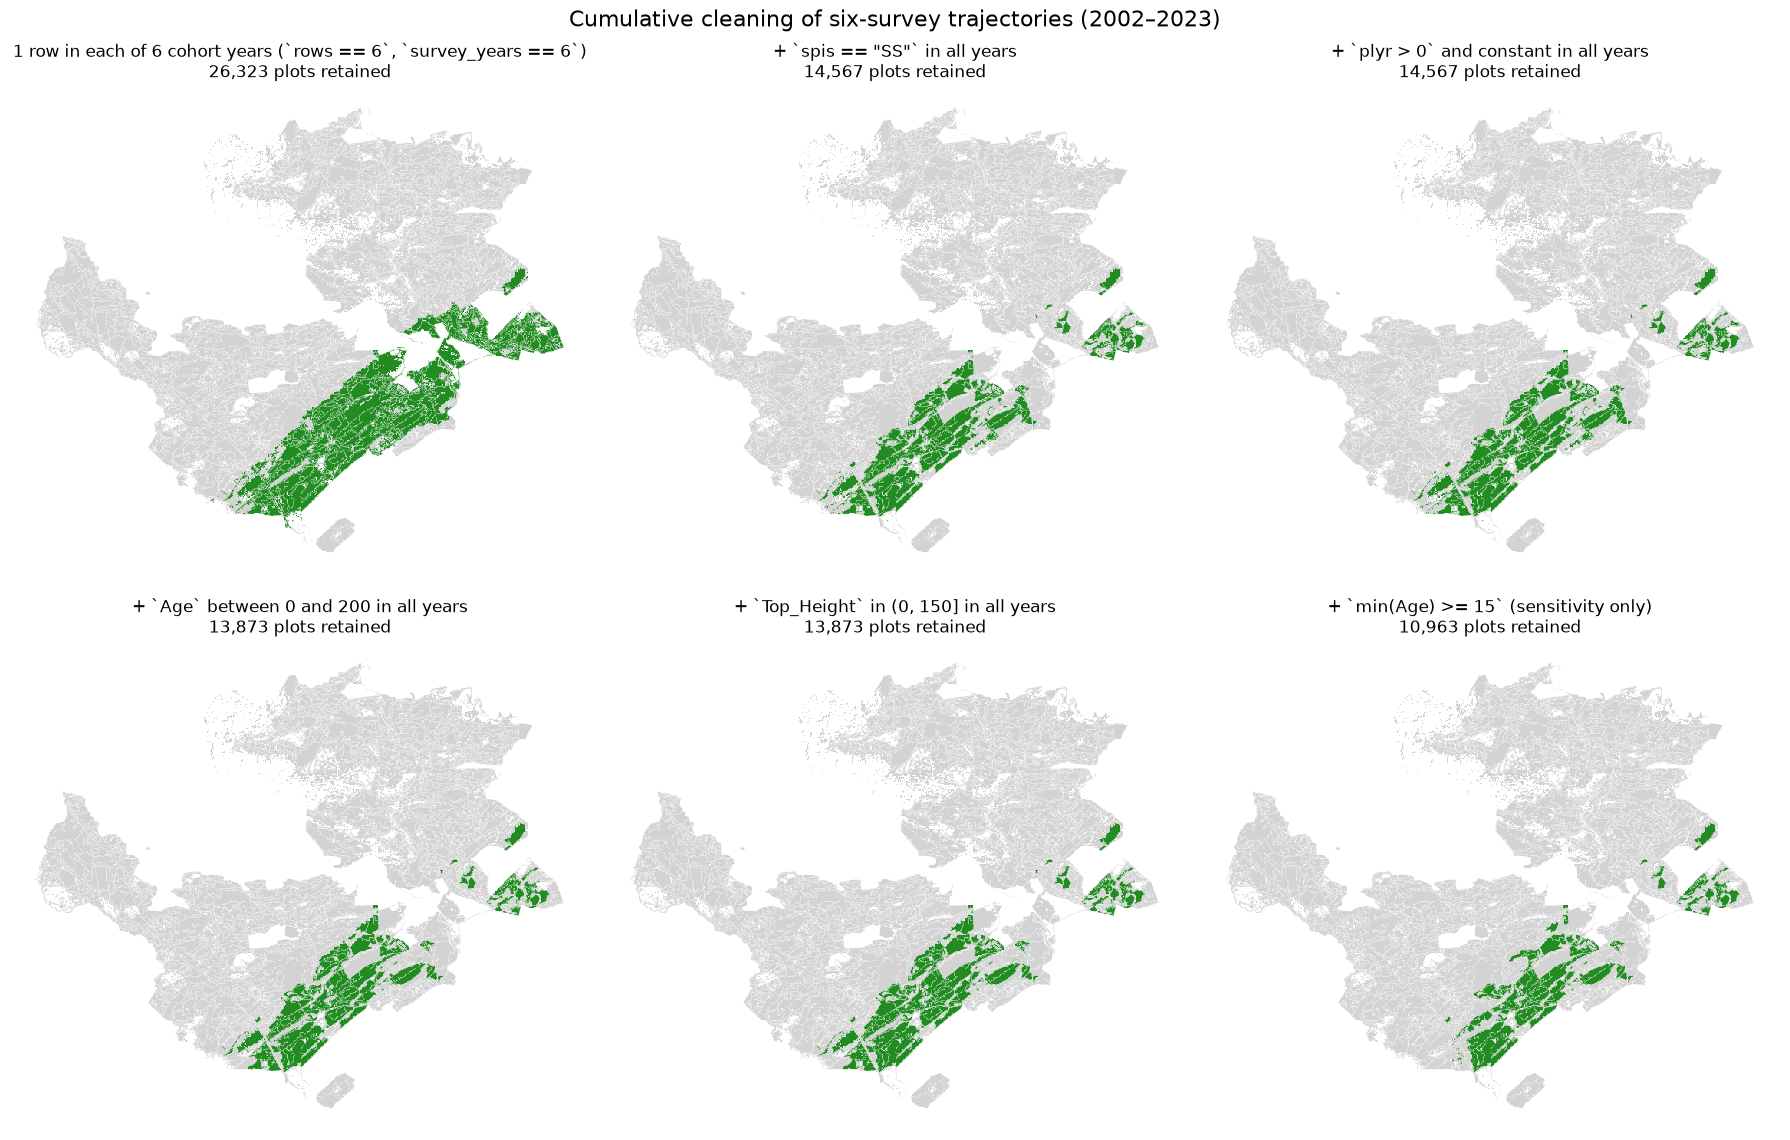

In [28]:
if not gpkg_path.exists():
    raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

spatial_data = gpd.read_file(gpkg_path, layer="LiDAR_Years")
geometry_issues = {
    "missing": int(spatial_data.geometry.isna().sum()),
    "empty": int(spatial_data.geometry.is_empty.sum()),
    "invalid": int((~spatial_data.geometry.is_valid).sum()),
}
print("CRS:", spatial_data.crs)
print("Geometry issues:", geometry_issues)

map_2023 = (
    spatial_data.loc[spatial_data["LiDAR_year"].eq(2023)]
    .drop_duplicates("identification")
    .copy()
)
stages_to_map = list(six_year_stages.items())
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

for (stage_name, stage_mask), axis in zip(stages_to_map, axes.flat):
    retained_ids = six_year_checks.index[stage_mask]
    retained_mask = map_2023["identification"].isin(retained_ids)
    map_2023.loc[~retained_mask].plot(ax=axis, color="lightgrey", linewidth=0)
    map_2023.loc[retained_mask].plot(ax=axis, color="forestgreen", linewidth=0)
    axis.set_title(f"{stage_name}\n{len(retained_ids):,} plots retained")
    axis.set_axis_off()
    axis.set_aspect("equal")

fig.suptitle("Cumulative cleaning of six-survey trajectories (2002–2023)", fontsize=16)
plt.tight_layout()
plt.show()

## 8. Keep cleaned datasets in notebook memory

The cleaned outputs are kept as notebook dataframes so you can continue processing cell-by-cell without creating files in `data/processed`. The dictionary below gives one place to access the cleaned tables and funnel summaries during the session.

In [29]:
cleaned_outputs = {
    "four_year_clean": four_year_clean,
    "six_year_clean": six_year_clean,
    "four_year_funnel": four_year_funnel,
    "six_year_funnel": six_year_funnel,
}

for name, table in cleaned_outputs.items():
    print(f"{name}: {len(table):,} rows")

four_year_clean: 171,460 rows
six_year_clean: 83,238 rows
four_year_funnel: 6 rows
six_year_funnel: 6 rows


## 9. Quick post-cleaning audit

The trajectory rules solve only the problems they explicitly test. This audit repeats the main data-quality checks on the cleaned cohorts to distinguish issues that have been removed from issues that remain. Counts are shown by cohort and survey year; percentages use the cleaned cohort as their denominator.

The audit checks:

- duplicate plot–year records and inconsistent planting years;
- missing species, zero yield class, age and height plausibility;
- canopy-cover and gap-fraction bounds;
- negative volume and extreme height;
- the different 2021 LAI scale and LAI values at the known 5.5 cap;
- irregular polygon area and disagreement between `block` and `blk`;
- exact mathematical redundancy among derived variables.

In [30]:
def audit_cleaned_cohort(data, cohort_name):
    def false_mask():
        return pd.Series(False, index=data.index)

    def area_difference_mask():
        if "Shape_Area" in data.columns:
            return pd.Series(~np.isclose(data["Shape_Area"], 400), index=data.index)
        if "area" in data.columns:
            return pd.Series(~np.isclose(data["area"], 400), index=data.index)
        if getattr(data, "geometry", None) is not None:
            return pd.Series(~np.isclose(data.geometry.area, 400), index=data.index)
        return false_mask()

    block_mismatch = (
        data["block"].astype(str).ne(data["blk"].astype(str))
        if {"block", "blk"}.issubset(data.columns)
        else false_mask()
    )

    checks = {
        "duplicate plot-year row": data.duplicated(["identification", "LiDAR_year"], keep=False),
        "missing species": data["spis"].isna(),
        "non-Sitka species": ~data["spis"].eq(TARGET_SPECIES),
        "planting year <= 0": data["plyr"].le(0),
        "age outside 0-200": ~data["Age"].between(MINIMUM_AGE, MAXIMUM_AGE),
        "height <= 0 or > 150 m": ~(data["Top_Height"].gt(0) & data["Top_Height"].le(150)),
        "canopy cover outside 0-1": ~data["CanopyCover"].between(0, 1),
        "gap fraction outside 0-1": ~data["GapFraction"].between(0, 1),
        "negative volume": data["Vol"].lt(0),
        "LAI > 5.5": data["LAI"].gt(5.5),
        "LAI = 5.5 cap": pd.Series(np.isclose(data["LAI"], 5.5), index=data.index),
        "area differs from 400 m2": area_difference_mask(),
        "block and blk disagree": block_mismatch,
        "yield class = 0": data["yldc"].eq(0),
        "height drop > 2 m": data["possible_disturbance"] if "possible_disturbance" in data.columns else false_mask(),
    }

    rows = []
    for issue, mask in checks.items():
        for year, year_mask in data.groupby("LiDAR_year").groups.items():
            count = int(mask.loc[year_mask].sum())
            rows.append({
                "cohort": cohort_name,
                "year": int(year),
                "issue": issue,
                "rows_affected": count,
                "percent_affected": round(100 * count / len(year_mask), 2),
            })
    return pd.DataFrame(rows)

post_cleaning_audit = pd.concat([
    audit_cleaned_cohort(four_year_clean, "four_year"),
    audit_cleaned_cohort(six_year_clean, "six_year"),
], ignore_index=True)

remaining_issue_summary = (
    post_cleaning_audit.groupby(["cohort", "issue"], as_index=False)
    .agg(rows_affected=("rows_affected", "sum"))
)
cohort_rows = {"four_year": len(four_year_clean), "six_year": len(six_year_clean)}
remaining_issue_summary["percent_of_cohort_rows"] = remaining_issue_summary.apply(
    lambda row: round(100 * row["rows_affected"] / cohort_rows[row["cohort"]], 2), axis=1
)
display(remaining_issue_summary.pivot(index="issue", columns="cohort", values=["rows_affected", "percent_of_cohort_rows"]))

rows_affected          percent_of_cohort_rows  \
cohort                       four_year six_year              four_year   
issue                                                                    
LAI = 5.5 cap                    480.0    434.0                   0.28   
LAI > 5.5                      16301.0   5090.0                   9.51   
age outside 0-200                  0.0      0.0                   0.00   
area differs from 400 m2       44616.0  20460.0                  26.02   
block and blk disagree             0.0      0.0                   0.00   
canopy cover outside 0-1           0.0      0.0                   0.00   
duplicate plot-year row            0.0      0.0                   0.00   
gap fraction outside 0-1           0.0      0.0                   0.00   
height <= 0 or > 150 m             0.0      0.0                   0.00   
height drop > 2 m               2376.0    531.0                   1.39   
missing species                    0.0      0.0                   0.00   
negative volume                 1242.0     85.0                   0.72   
non-Sitka species                  0.0      0.0                   0.00   
planting year <= 0                 0.0      0.0                   0.00   
yield class = 0                    0.0      0.0                   0.00   

                                   
cohort                   six_year  
issue                              
LAI = 5.5 cap                0.52  
LAI > 5.5                    6.11  
age outside 0-200            0.00  
area differs from 400 m2    24.58  
block and blk disagree       0.00  
canopy cover outside 0-1     0.00  
duplicate plot-year row      0.00  
gap fraction outside 0-1     0.00  
height <= 0 or > 150 m       0.00  
height drop > 2 m            0.64  
missing species              0.00  
negative volume              0.10  
non-Sitka species            0.00  
planting year <= 0           0.00  
yield class = 0              0.00

### 9.1 Are age and planting year still issues after selecting Sitka spruce?

For these data, the **known and consistent planting-year rule may remove no additional plots after confirmed Sitka spruce is selected**. If the funnel shows zero plots dropped at that stage, then your observation is correct for this particular subset: the Sitka filter has already selected records with complete planting-year information.

That does **not** prove the planting year is historically correct. `Age` is calculated exactly as `LiDAR_year - plyr`, so agreement between age and planting year is not independent validation. Both fields also come from the linked 2025 inventory context. A plot can pass all numerical checks while its current planting year describes a later rotation rather than the trees present in an early LiDAR survey.

Interpret the result as: *missing, zero, inconsistent, and numerically impossible planting years have been removed from this cohort*. Historical correctness remains an untested limitation. The age-15 condition is still optional and should not be described as error correction.

### 9.2 Which variable concerns can remain?

The cleaning rules directly guarantee species, planting-year completeness, age range, height range, and one record per survey. They do not clean most other measurements.

- **LAI:** the 2021 processing-scale difference remains. Selecting clean Sitka trajectories does not harmonise LAI. Values above 5.5 should occur only in 2021, while other years may pile up exactly at the 5.5 cap. Do not model raw LAI longitudinally until its formula is confirmed or a defensible harmonisation is developed.
- **Volume:** negative values can remain because volume was not part of trajectory selection. They should be reviewed before volume modelling; they do not invalidate a top-height-only model.
- **Canopy cover and gap fraction:** valid bounds may remain, but the two variables are exact complements (`CanopyCover + GapFraction = 1`). Use at most one as a predictor.
- **Top height and 95th percentile elevation:** top height remains exactly derived from the percentile (`Top_Height = 1.1 × elev_percentile_95th`). Do not use both as independent predictors.
- **Age and planting year:** age is derived from survey year and planting year. In a growth model, this is intended as the time variable, but it is not independent evidence.
- **Area:** a polygon area different from 400 m² may reflect boundary clipping rather than an erroneous record. It is spatial context, not an automatic exclusion.
- **Height decreases:** these remain intentionally and are flagged as possible disturbance. Decide whether to model, stratify, or exclude them based on the scientific question.

In [31]:
identity_checks = pd.DataFrame({
    "relationship": [
        "CanopyCover + GapFraction = 1",
        "Top_Height = 1.1 * elev_percentile_95th",
        "Age = LiDAR_year - plyr",
    ],
    "four_year_rows_not_matching": [
        int((~np.isclose(four_year_clean["CanopyCover"] + four_year_clean["GapFraction"], 1)).sum()),
        int((~np.isclose(four_year_clean["Top_Height"], 1.1 * four_year_clean["elev_percentile_95th"])).sum()),
        int((~np.isclose(four_year_clean["Age"], four_year_clean["LiDAR_year"] - four_year_clean["plyr"])).sum()),
    ],
    "six_year_rows_not_matching": [
        int((~np.isclose(six_year_clean["CanopyCover"] + six_year_clean["GapFraction"], 1)).sum()),
        int((~np.isclose(six_year_clean["Top_Height"], 1.1 * six_year_clean["elev_percentile_95th"])).sum()),
        int((~np.isclose(six_year_clean["Age"], six_year_clean["LiDAR_year"] - six_year_clean["plyr"])).sum()),
    ],
})
display(identity_checks)

lai_by_year = six_year_clean.groupby("LiDAR_year")["LAI"].agg(
    rows="size", median="median", maximum="max"
)
lai_by_year["rows_above_5.5"] = six_year_clean["LAI"].gt(5.5).groupby(six_year_clean["LiDAR_year"]).sum()
lai_at_cap = pd.Series(np.isclose(six_year_clean["LAI"], 5.5), index=six_year_clean.index)
lai_by_year["rows_at_5.5"] = lai_at_cap.groupby(six_year_clean["LiDAR_year"]).sum()
display(lai_by_year.round(3))

,relationship,four_year_rows_not_matching,six_year_rows_not_matching
0,CanopyCover + GapFraction = 1,0,0
1,Top_Height = 1.1 * elev_percentile_95th,0,0
2,Age = LiDAR_year - plyr,0,0


,rows,median,maximum,rows_above_5.5,rows_at_5.5
LiDAR_year,,,,,
2002,13873,0.827,5.500,0,9
2006,13873,1.005,5.500,0,215
2008,13873,0.646,2.830,0,0
2012,13873,0.772,5.500,0,210
2021,13873,4.433,18.048,5090,0
2023,13873,0.797,2.486,0,0


## 10. Quick distributions after cleaning

These year-specific box plots provide a rough comparison without pooling surveys. They do not remove statistical outliers. LAI is plotted separately because the different 2021 scale would compress the other measurements and is itself a key diagnostic.

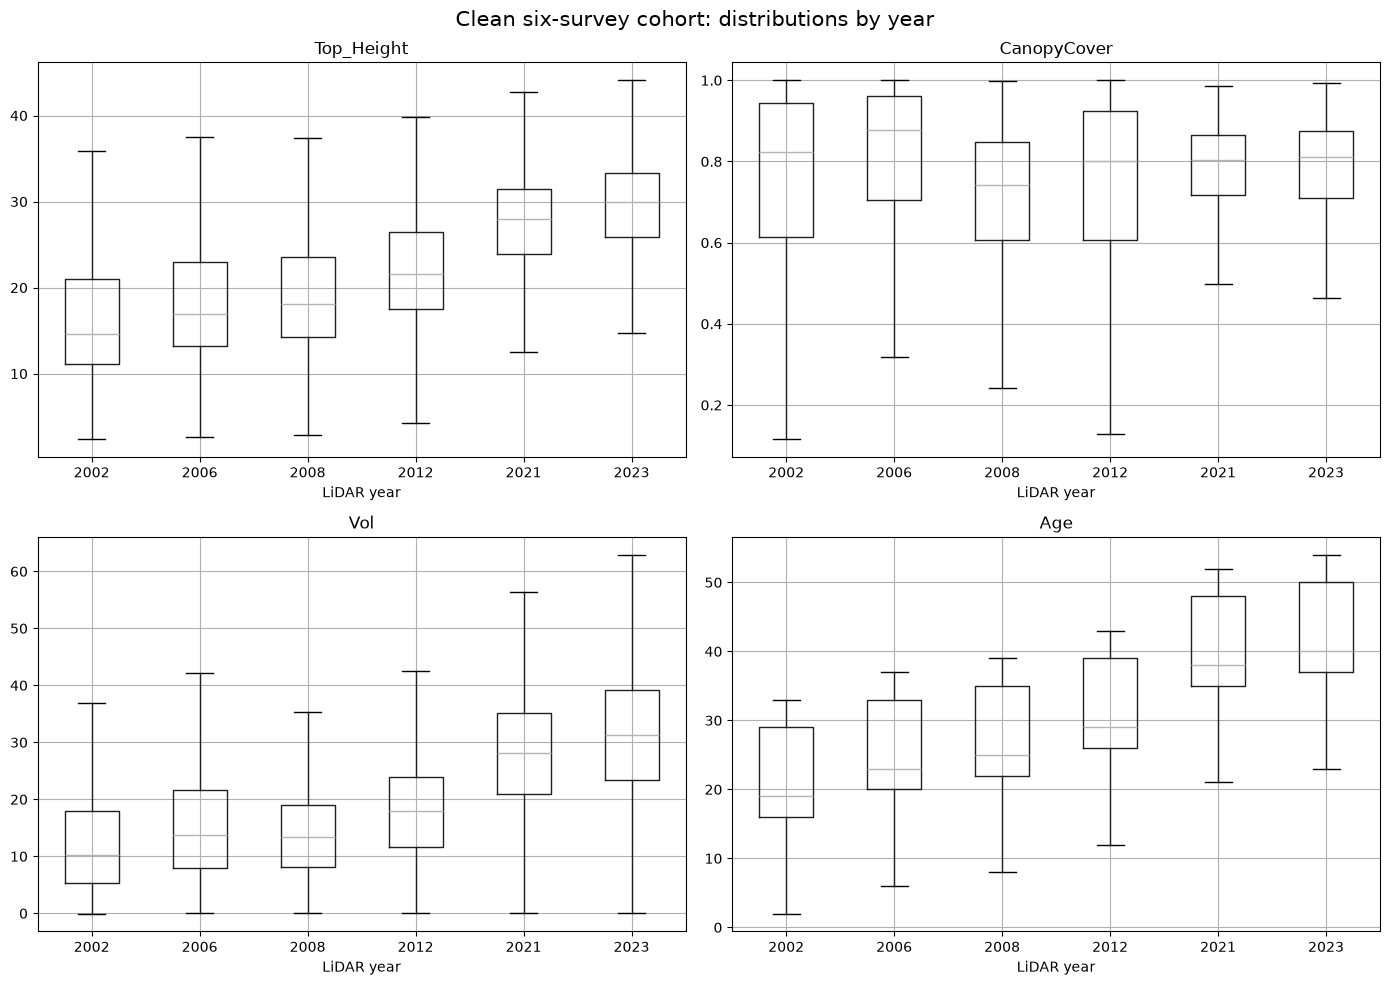

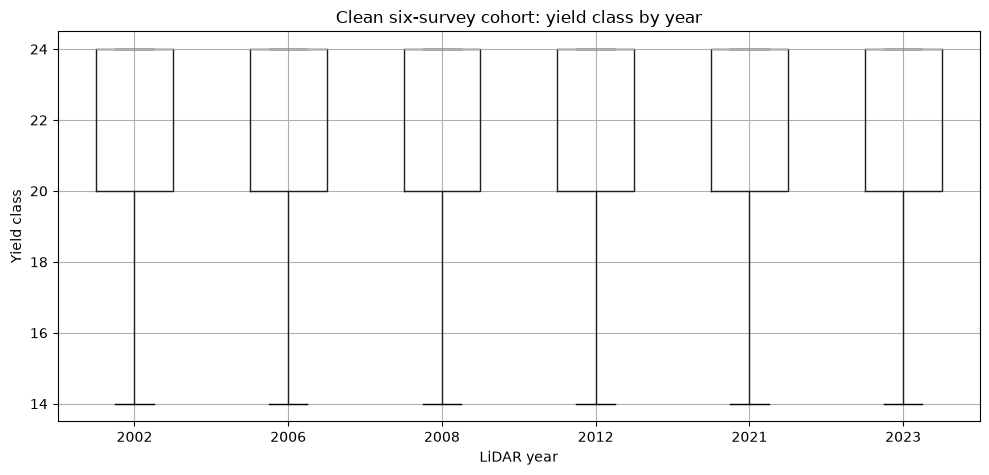

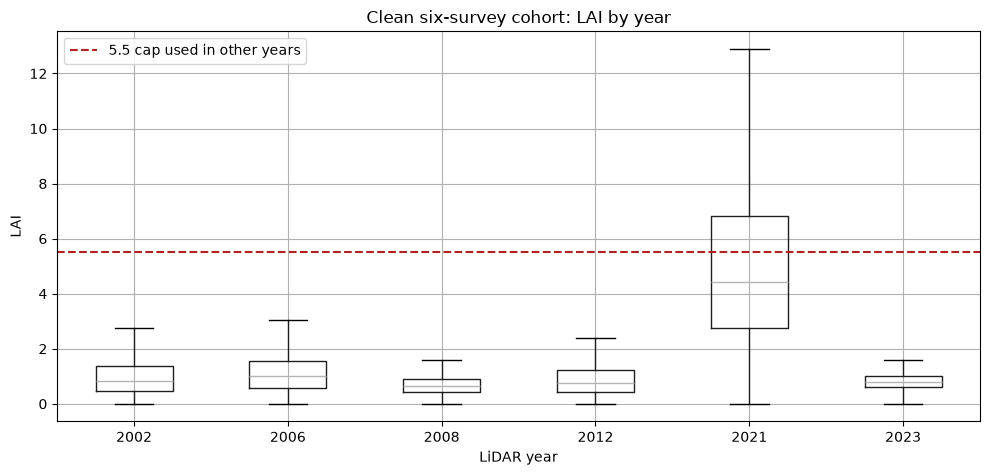

In [32]:
variables = ["Top_Height", "CanopyCover", "Vol", "Age"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variable, axis in zip(variables, axes.flat):
    six_year_clean.boxplot(column=variable, by="LiDAR_year", ax=axis, showfliers=False)
    axis.set_title(variable)
    axis.set_xlabel("LiDAR year")
fig.suptitle("Clean six-survey cohort: distributions by year", fontsize=15)
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(10, 5))
six_year_clean.boxplot(column="yldc", by="LiDAR_year", ax=axis, showfliers=False)
axis.set_title("Clean six-survey cohort: yield class by year")
axis.set_xlabel("LiDAR year")
axis.set_ylabel("Yield class")
plt.suptitle("")
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(10, 5))
six_year_clean.boxplot(column="LAI", by="LiDAR_year", ax=axis, showfliers=False)
axis.axhline(5.5, color="firebrick", linestyle="--", label="5.5 cap used in other years")
axis.set_title("Clean six-survey cohort: LAI by year")
axis.set_xlabel("LiDAR year")
axis.set_ylabel("LAI")
axis.legend()
plt.suptitle("")
plt.tight_layout()
plt.show()

### 10.1 Volume versus top height: which target is cleaner?

For the cleaned six-survey cohort, top height is the safer response variable unless the volume field is explicitly repaired. The checks below quantify three things:

- how many cleaned rows have valid `Top_Height` and valid `Vol`;
- whether negative volume rows also have invalid or negative height;
- which variables are exact or near-exact derivations of others, so they should not be treated as independent predictors.

In [33]:
negative_volume_rows = six_year_clean.loc[six_year_clean["Vol"].lt(0)].copy()
negative_volume_rows["Top_Height_negative"] = negative_volume_rows["Top_Height"].lt(0)
negative_volume_rows["Top_Height_nonpositive"] = negative_volume_rows["Top_Height"].le(0)
negative_volume_rows["Top_Height_outside_rule"] = ~(
    negative_volume_rows["Top_Height"].gt(0) & negative_volume_rows["Top_Height"].le(MAXIMUM_HEIGHT)
)

validity_summary = pd.DataFrame([
    {
        "metric": "Top_Height",
        "usable_rows": int((six_year_clean["Top_Height"].gt(0) & six_year_clean["Top_Height"].le(MAXIMUM_HEIGHT)).sum()),
        "total_rows": len(six_year_clean),
    },
    {
        "metric": "Vol",
        "usable_rows": int(six_year_clean["Vol"].ge(0).sum()),
        "total_rows": len(six_year_clean),
    },
])
validity_summary["percent_usable"] = (100 * validity_summary["usable_rows"] / validity_summary["total_rows"]).round(2)

negative_volume_summary = pd.DataFrame([
    {
        "check": "Rows with negative volume",
        "count": len(negative_volume_rows),
    },
    {
        "check": "Negative volume and negative Top_Height",
        "count": int(negative_volume_rows["Top_Height_negative"].sum()),
    },
    {
        "check": "Negative volume and non-positive Top_Height",
        "count": int(negative_volume_rows["Top_Height_nonpositive"].sum()),
    },
    {
        "check": "Negative volume but Top_Height still passes cleaning rule",
        "count": int((~negative_volume_rows["Top_Height_outside_rule"]).sum()),
    },
])

display(validity_summary)
display(negative_volume_summary)

if negative_volume_rows.empty:
    print("No negative volume rows remain in the cleaned six-survey cohort.")
else:
    display(
        negative_volume_rows.groupby("LiDAR_year").agg(
            rows_with_negative_volume=("Vol", "size"),
            min_volume=("Vol", "min"),
            median_top_height=("Top_Height", "median"),
            min_top_height=("Top_Height", "min"),
            max_top_height=("Top_Height", "max"),
        )
    )

,metric,usable_rows,total_rows,percent_usable
0,Top_Height,83238,83238,100.0
1,Vol,83153,83238,99.9


,check,count
0,Rows with negative volume,85
1,Negative volume and negative Top_Height,0
2,Negative volume and non-positive Top_Height,0
3,Negative volume but Top_Height still passes cl...,85


,rows_with_negative_volume,min_volume,median_top_height,min_top_height,max_top_height
LiDAR_year,,,,,
2002,55,-0.044231,3.168340,2.399554,3.431399
2006,5,-0.009851,3.013185,2.618829,3.390482
2008,3,-0.006800,3.137858,2.923686,3.267956
2012,4,-0.003084,3.288702,2.993942,3.385444
2021,15,-0.003653,3.076106,2.366836,3.426403
2023,3,-0.004770,2.969722,2.806608,3.213884


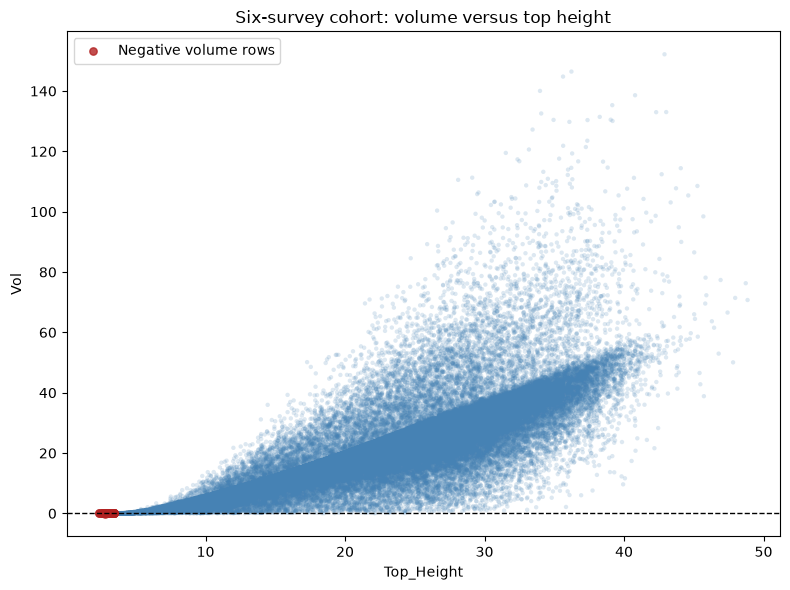

In [34]:
fig, axis = plt.subplots(figsize=(8, 6))
valid_scatter = six_year_clean.loc[six_year_clean["Vol"].notna() & six_year_clean["Top_Height"].notna()]
axis.scatter(valid_scatter["Top_Height"], valid_scatter["Vol"], s=10, alpha=0.18, color="steelblue", edgecolor="none")
if not negative_volume_rows.empty:
    axis.scatter(
        negative_volume_rows["Top_Height"],
        negative_volume_rows["Vol"],
        s=28,
        alpha=0.8,
        color="firebrick",
        label="Negative volume rows",
    )
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set_title("Six-survey cohort: volume versus top height")
axis.set_xlabel("Top_Height")
axis.set_ylabel("Vol")
if not negative_volume_rows.empty:
    axis.legend()
plt.tight_layout()
plt.show()

#when top height is larger, is volume usually larger too?
#where do the negative-volume rows sit relative to the main cloud?

In [35]:
variable_dependency_summary = pd.DataFrame([
    {
        "variable": "Age",
        "depends_on": "LiDAR_year and plyr",
        "relationship": "Age = LiDAR_year - plyr",
        "status_in_cleaned_data": "Exact derivation",
    },
    {
        "variable": "Top_Height",
        "depends_on": "elev_percentile_95th",
        "relationship": "Top_Height = 1.1 * elev_percentile_95th",
        "status_in_cleaned_data": "Exact derivation",
    },
    {
        "variable": "GapFraction",
        "depends_on": "CanopyCover",
        "relationship": "GapFraction = 1 - CanopyCover",
        "status_in_cleaned_data": "Exact derivation",
    },
    {
        "variable": "CanopyCover",
        "depends_on": "GapFraction",
        "relationship": "CanopyCover = 1 - GapFraction",
        "status_in_cleaned_data": "Exact derivation",
    },
    {
        "variable": "Vol",
        "depends_on": "Top_Height plus other inventory or model inputs not reconstructed here",
        "relationship": "Not independently measurable from this table alone",
        "status_in_cleaned_data": "Derived metric requiring separate validation",
    },
    {
        "variable": "LAI",
        "depends_on": "Remote-sensing processing pipeline",
        "relationship": "Year-specific processing difference remains, especially 2021",
        "status_in_cleaned_data": "Not independent of processing choices",
    },
])

display(variable_dependency_summary)

,variable,depends_on,relationship,status_in_cleaned_data
0,Age,LiDAR_year and plyr,Age = LiDAR_year - plyr,Exact derivation
1,Top_Height,elev_percentile_95th,Top_Height = 1.1 * elev_percentile_95th,Exact derivation
2,GapFraction,CanopyCover,GapFraction = 1 - CanopyCover,Exact derivation
3,CanopyCover,GapFraction,CanopyCover = 1 - GapFraction,Exact derivation
4,Vol,Top_Height plus other inventory or model input...,Not independently measurable from this table a...,Derived metric requiring separate validation
5,LAI,Remote-sensing processing pipeline,"Year-specific processing difference remains, e...",Not independent of processing choices


### 10.2 Correlation matrices for the cleaned cohorts

The spatial maps below are only a **subset** of the remaining concerns. The audit table above is the full list. For example, clipped area, LAI values at the 5.5 cap, and exact variable dependencies are still important, but they are less informative to map directly.

The matrices below are calculated on the cleaned rows only, pooling all years within each cohort. They are useful as a rough exploratory summary, but several strong relationships are **mechanical rather than biological**:

- `Age` and `plyr` are tied through `LiDAR_year`.
- `Top_Height` is exactly derived from `elev_percentile_95th`.
- `CanopyCover` and `GapFraction` are exact complements.
- `Vol` is likely model-derived from height and other stand inputs not reconstructed here.

Spearman correlation is used because several variables are bounded, skewed, or on very different scales.

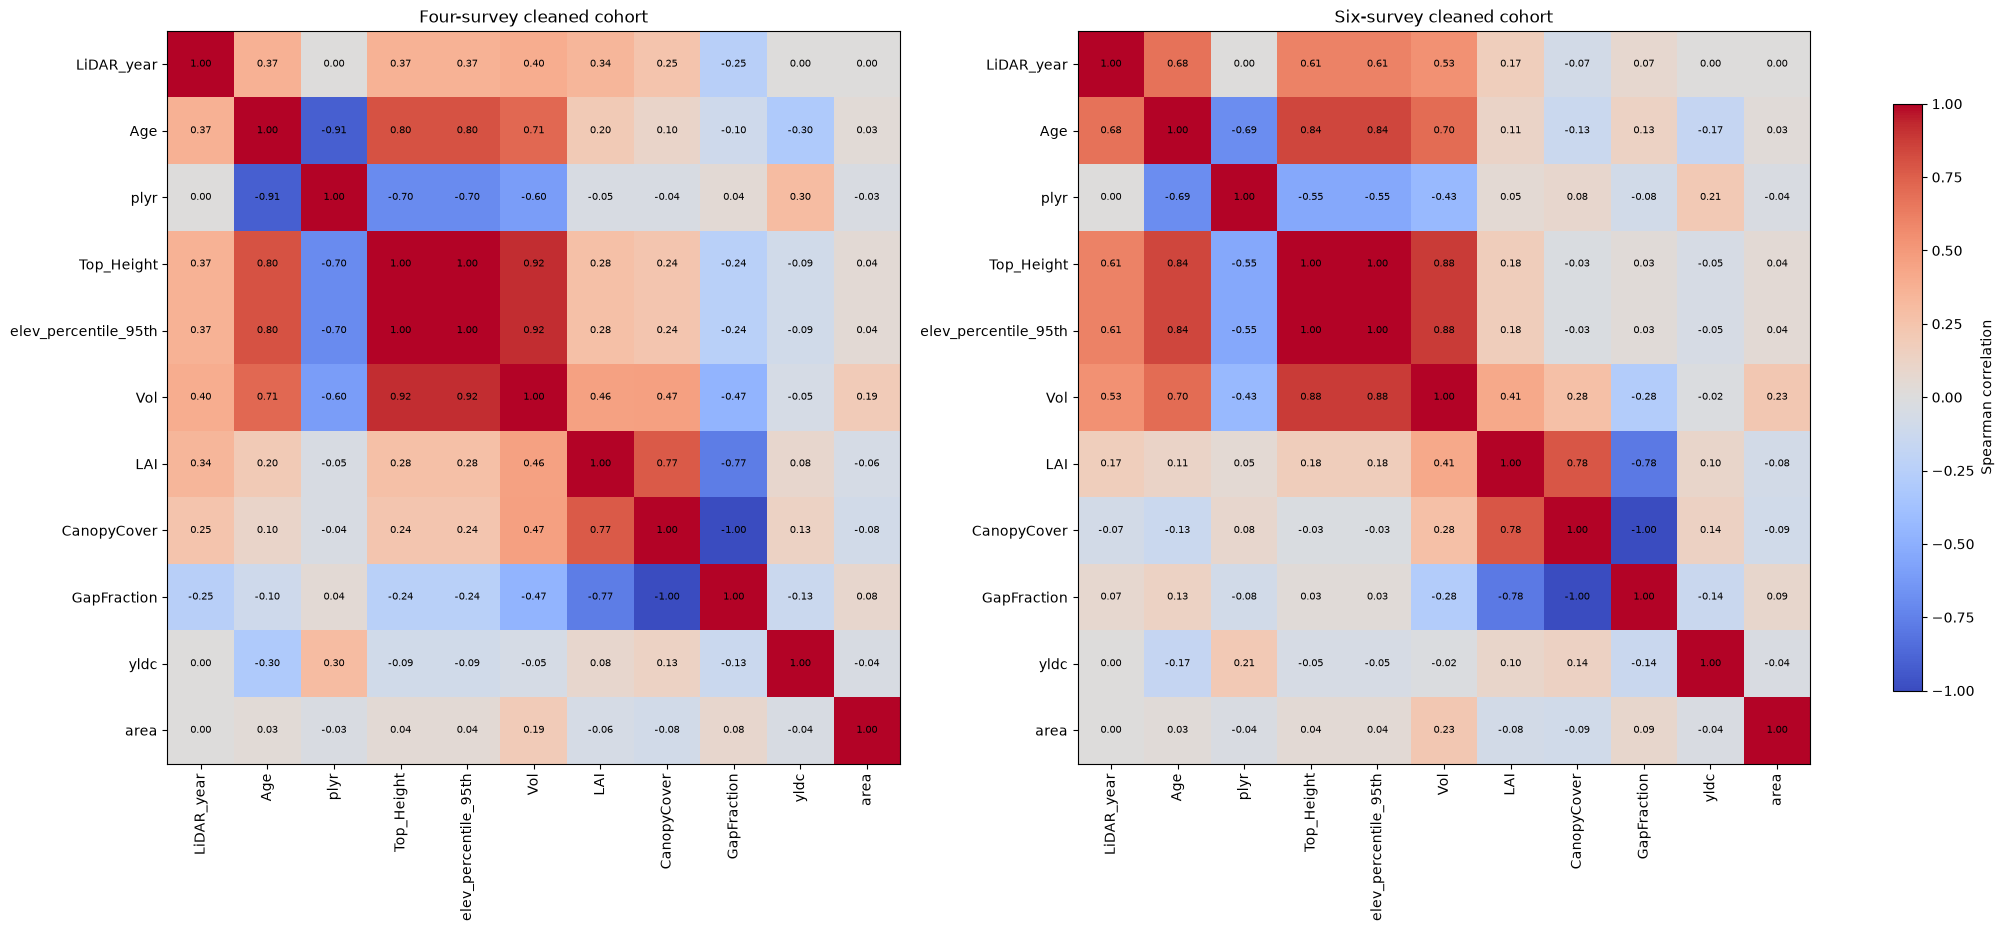

In [36]:
correlation_variables = [
    "LiDAR_year",
    "Age",
    "plyr",
    "Top_Height",
    "elev_percentile_95th",
    "Vol",
    "LAI",
    "CanopyCover",
    "GapFraction",
    "yldc",
    "area",
]

def plot_correlation_matrix(axis, data, title, variables):
    corr = data[variables].corr(method="spearman")
    image = axis.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_xticks(range(len(variables)))
    axis.set_xticklabels(variables, rotation=90)
    axis.set_yticks(range(len(variables)))
    axis.set_yticklabels(variables)
    axis.set_title(title)
    for row in range(len(variables)):
        for col in range(len(variables)):
            axis.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=7)
    return image

fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
image = plot_correlation_matrix(axes[0], four_year_clean, "Four-survey cleaned cohort", correlation_variables)
plot_correlation_matrix(axes[1], six_year_clean, "Six-survey cleaned cohort", correlation_variables)
fig.colorbar(image, ax=axes, shrink=0.8, label="Spearman correlation")
plt.show()

## 11. Spatial visualisations of the cleaned cohorts

The first map compares all 2023 coverage with the final four- and six-survey cohorts. The second locates six-survey plots with at least one height drop greater than 2 m. The third maps the two remaining measurement concerns most relevant to a quick audit: LAI above 5.5 in 2021 and negative volume in any survey. Clustering would suggest a spatially structured processing, coverage, or disturbance effect rather than random isolated errors.

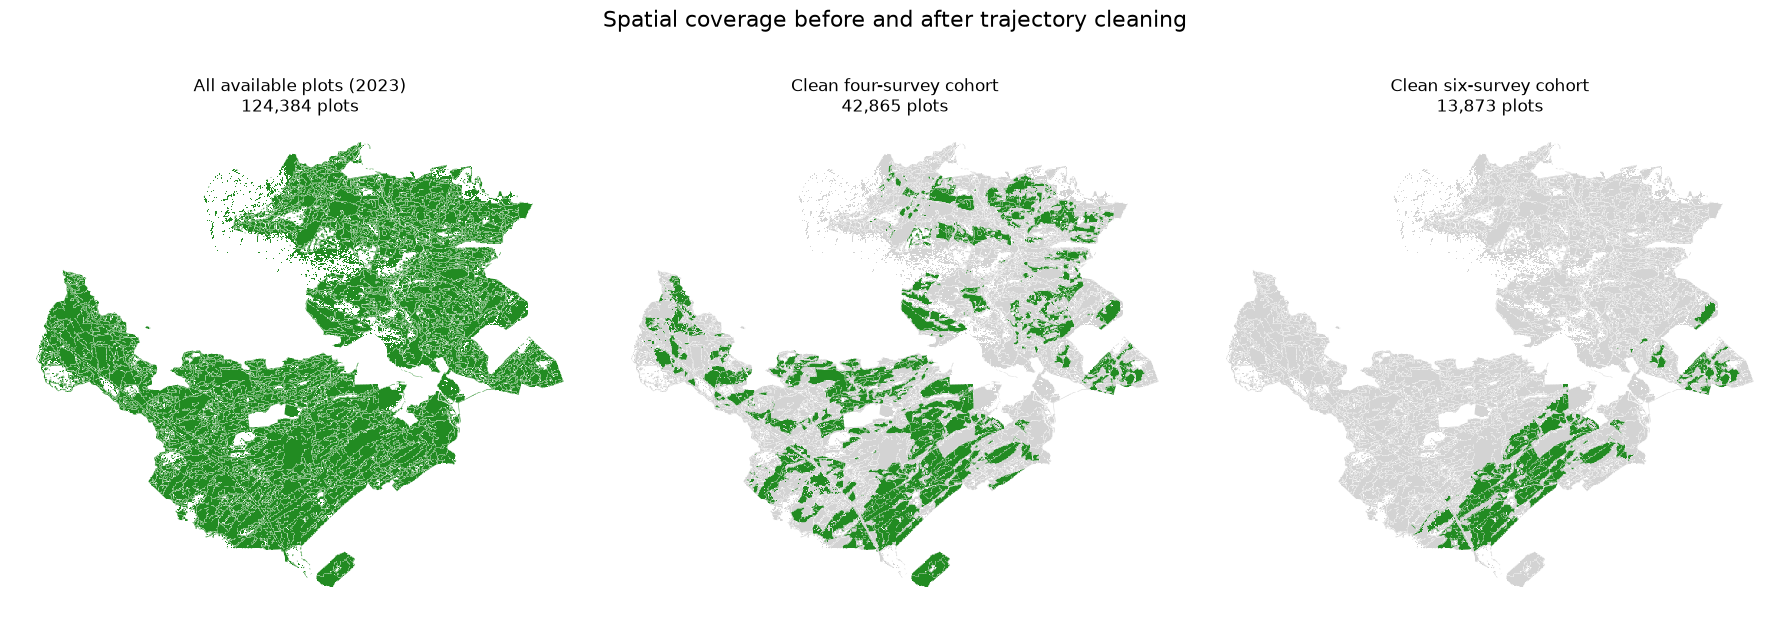

In [37]:
four_year_ids = four_year_clean["identification"].unique()
six_year_ids = six_year_clean["identification"].unique()
coverage_maps = {
    "All available plots (2023)": map_2023.index,
    "Clean four-survey cohort": four_year_ids,
    "Clean six-survey cohort": six_year_ids,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)
for (title, ids), axis in zip(coverage_maps.items(), axes):
    if title.startswith("All"):
        selected = map_2023
    else:
        selected = map_2023.loc[map_2023["identification"].isin(ids)]
        map_2023.plot(ax=axis, color="lightgrey", linewidth=0)
    selected.plot(ax=axis, color="forestgreen", linewidth=0)
    axis.set_title(f"{title}\n{len(selected):,} plots")
    axis.set_axis_off()
    axis.set_aspect("equal")
fig.suptitle("Spatial coverage before and after trajectory cleaning", fontsize=16)
plt.tight_layout()
plt.show()

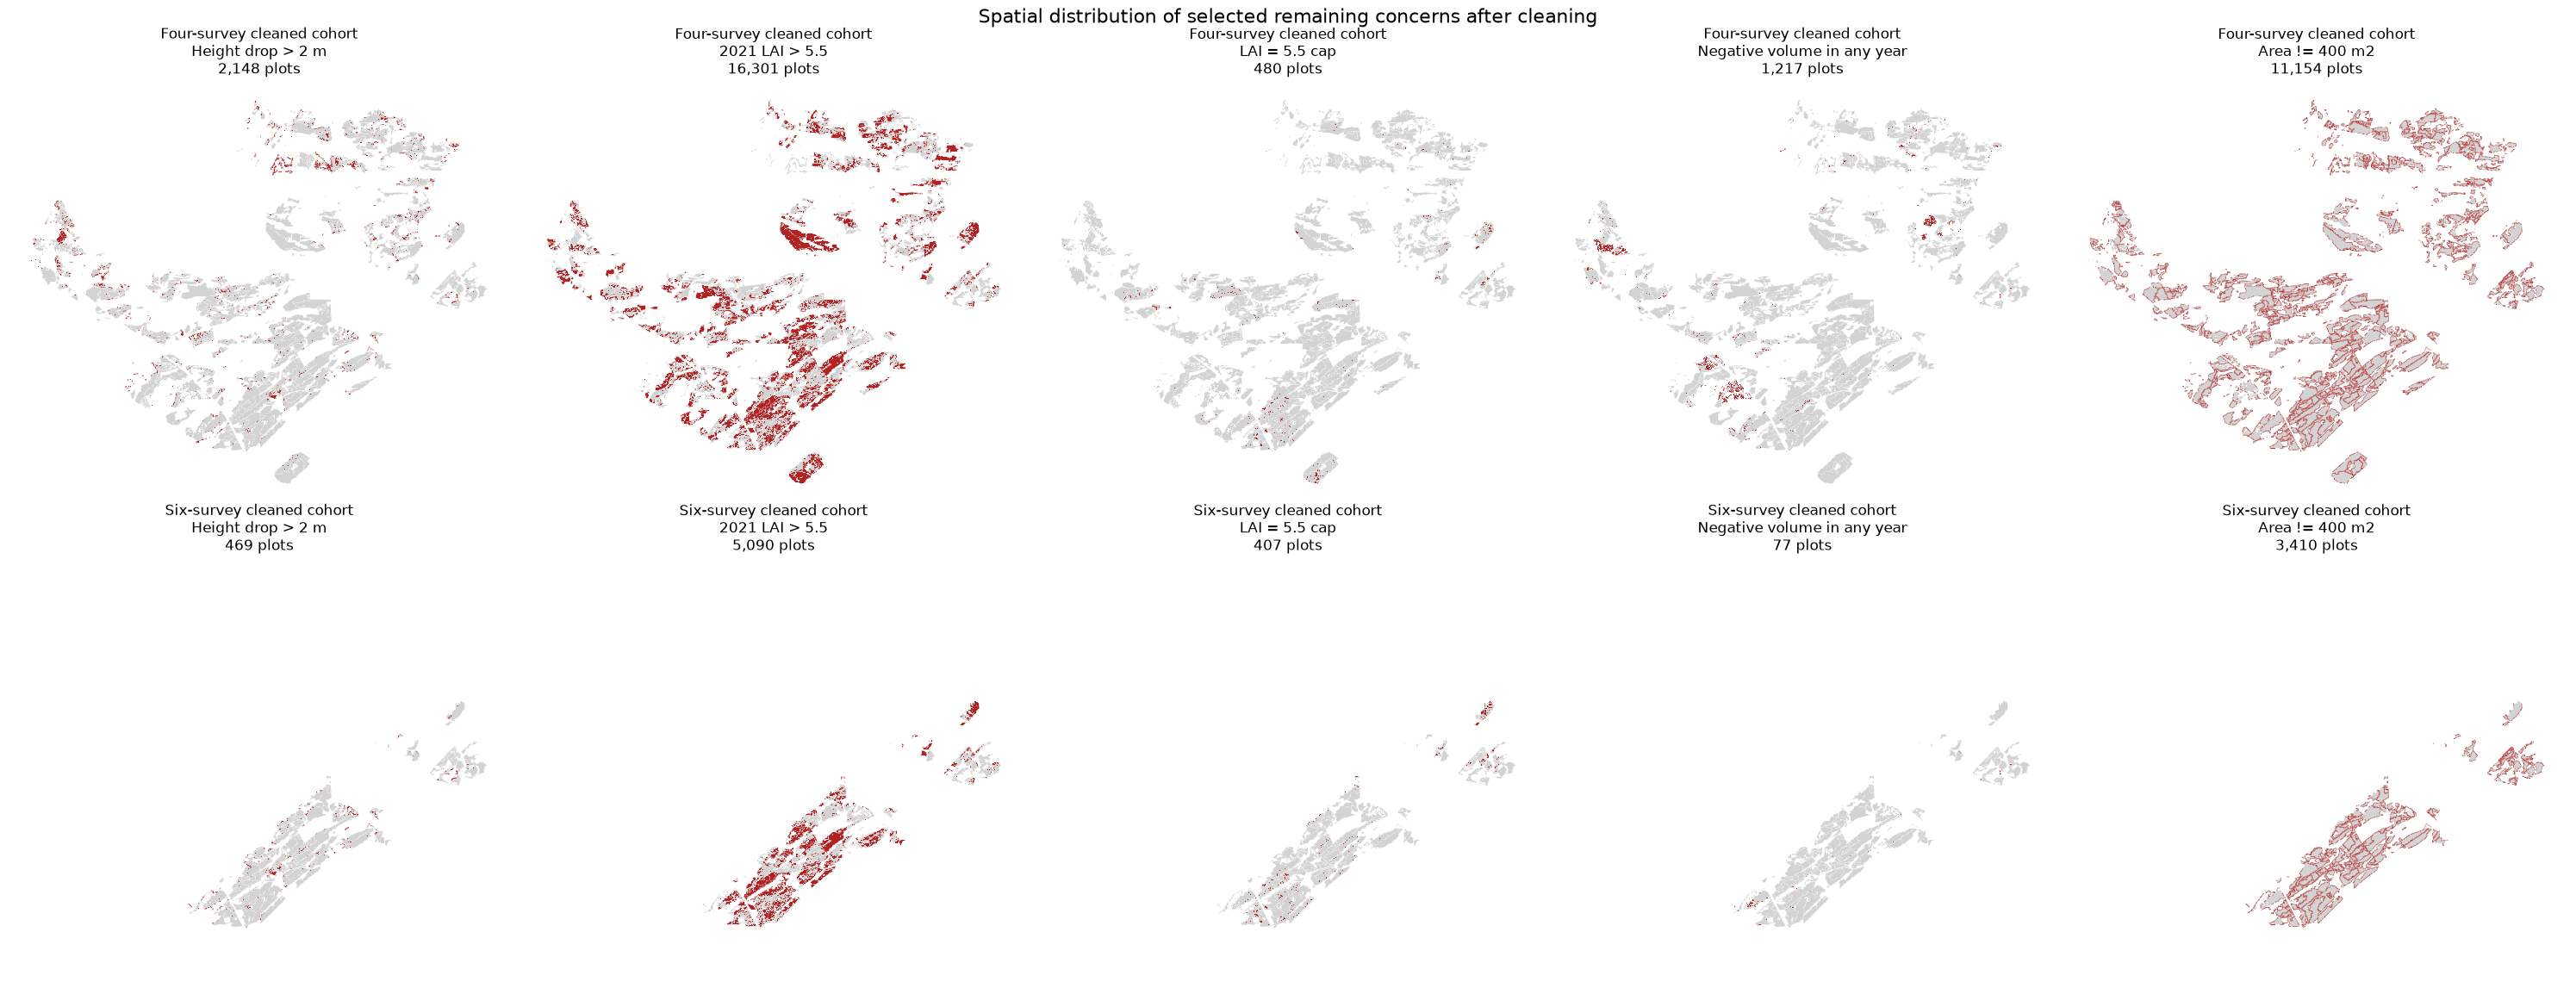

In [38]:
def plot_level_issue_ids(data):
    disturbed_ids = (
        data.groupby("identification")["possible_disturbance"].any().loc[lambda values: values].index
        if "possible_disturbance" in data.columns
        else pd.Index([])
    )
    lai_high_ids = data.loc[
        data["LiDAR_year"].eq(2021) & data["LAI"].gt(5.5), "identification"
    ].unique()
    lai_cap_ids = data.loc[np.isclose(data["LAI"], 5.5), "identification"].unique()
    negative_volume_ids = data.loc[data["Vol"].lt(0), "identification"].unique()
    if "area" in data.columns:
        irregular_area_ids = data.loc[~np.isclose(data["area"], 400), "identification"].unique()
    else:
        irregular_area_ids = np.array([])
    return {
        "Height drop > 2 m": disturbed_ids,
        "2021 LAI > 5.5": lai_high_ids,
        "LAI = 5.5 cap": lai_cap_ids,
        "Negative volume in any year": negative_volume_ids,
        "Area != 400 m2": irregular_area_ids,
    }

cohort_issue_maps = {
    "Four-survey cleaned cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(four_year_ids)],
        "issues": plot_level_issue_ids(four_year_clean),
    },
    "Six-survey cleaned cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(six_year_ids)],
        "issues": plot_level_issue_ids(six_year_clean),
    },
}

issue_titles = list(next(iter(cohort_issue_maps.values()))["issues"].keys())
fig, axes = plt.subplots(2, len(issue_titles), figsize=(6 * len(issue_titles), 12), sharex=True, sharey=True)

for row, (cohort_name, details) in enumerate(cohort_issue_maps.items()):
    cohort_map = details["map"]
    for col, issue_name in enumerate(issue_titles):
        axis = axes[row, col]
        cohort_map.plot(ax=axis, color="lightgrey", linewidth=0)
        affected_ids = details["issues"][issue_name]
        affected = cohort_map.loc[cohort_map["identification"].isin(affected_ids)]
        if not affected.empty:
            affected.plot(ax=axis, color="firebrick", linewidth=0)
        axis.set_title(f"{cohort_name}\n{issue_name}\n{len(affected):,} plots")
        axis.set_axis_off()
        axis.set_aspect("equal")

fig.suptitle("Spatial distribution of selected remaining concerns after cleaning", fontsize=16)
plt.tight_layout()
plt.show()

## 12. Cleaning decisions and limitations

### Structural filtering used to create the cleaned cohorts

The cleaned datasets were created using these structural filters:

- `identification`  Keep only plots with a complete repeated history across the cohort years.

- `survey_count` / repeated year coverage  
  Four-year cohort: keep only plots present in all 4 required LiDAR years.  
  Six-year cohort: keep only plots present in all 6 required LiDAR years.

- `Species`  Keep only Sitka spruce records for the Sitka-focused analysis.

- `identification` duplicated across years, Keep only records where `identification` can be used consistently to track the same plot through time.

### Issues checked after cleaning, but not automatically filtered out

- `Vol`  Checked for negative values.

- `LAI`  Checked for values above `5.5`, especially in 2021, and for values exactly equal to the `5.5` cap.

- `area` / `Shape_Area`  Checked for plots where area is not close to `400 m²`.

- `possible_disturbance` / `Top_Height` over time.   Checked for height drops greater than `2 m` between surveys.

---

After running the notebook, use the funnel and audit tables to report exact counts. The correct high-level interpretation is:

- **Resolved by construction:** incomplete trajectories, repeated plot–year rows, non-Sitka or missing species labels, unknown/inconsistent planting year, age outside 0–200, and height outside 0–150 m.
- **Still present and requiring a modelling decision:** the 2021 LAI scale, possible negative volume, capped LAI, disturbed or shrinking trajectories, clipped plot areas, and redundant derived variables.
- **Not testable from this table alone:** historical accuracy of 2025-linked species and planting year, unchanged geometry, and the cause of height decreases.

The cleaned cohorts are therefore suitable starting points for exploratory **top-height versus age** work. They should not be called universally clean datasets, and raw LAI or volume should not enter a longitudinal model until their remaining issues have been addressed.

The source CSV and GeoPackage remain unchanged. The core outputs do not impose a minimum starting age of 15; that threshold is retained only in the funnel as a sensitivity analysis.

## 13. Thinning history versus measurable structural disturbance

There is no explicit `last_felled_date` field in the current attribute table. The management fields available here are `last_thinn` and `next_thin_`, which appear to represent thinning years rather than clear-felling dates.

This section therefore asks a narrower and more defensible question: **does recent thinning history align better with drops in `Top_Height` or with drops in `Vol`?**

To keep the analysis simple, the notebook now uses one main rule set:

- **recent thinning** = `last_thinn` within **5 years** before a LiDAR survey;
- **top-height disturbance** = `Top_Height_change <= -2`;
- **volume disturbance** = `Vol_change <= -10`.

These are not proofs of felling. They are simple disturbance definitions used to test whether recorded thinning history is more closely aligned with height loss or with volume loss.


In [48]:
THINNING_ALIGNMENT_RULES = {
    "recent_thinning_window_years": 5,
    "top_height_drop_threshold": 2.0,
    "volume_drop_threshold": 10.0,
}


def build_disturbance_alignment_tables(cleaned):
    ordered = cleaned.sort_values(["identification", "LiDAR_year"]).copy()
    grouped = ordered.groupby("identification", sort=False)

    for variable in ["CanopyCover", "Top_Height", "LAI", "Vol"]:
        ordered[f"{variable}_change"] = grouped[variable].diff()

    ordered["last_thinn_valid"] = ordered["last_thinn"].where(ordered["last_thinn"].gt(0))
    ordered["years_since_last_thin"] = ordered["LiDAR_year"] - ordered["last_thinn_valid"]
    ordered["recent_thinning_record"] = ordered["years_since_last_thin"].between(
        0, THINNING_ALIGNMENT_RULES["recent_thinning_window_years"]
    )

    ordered["top_height_disturbance"] = ordered["Top_Height_change"].le(
        -THINNING_ALIGNMENT_RULES["top_height_drop_threshold"]
    )
    ordered["volume_disturbance"] = ordered["Vol_change"].le(
        -THINNING_ALIGNMENT_RULES["volume_drop_threshold"]
    )
    ordered["combined_structural_disturbance"] = (
        ordered["top_height_disturbance"]
        | ordered["volume_disturbance"]
        | ordered["possible_disturbance"].fillna(False)
    )

    plot_summary = grouped.agg(
        any_recent_thinning=("recent_thinning_record", "any"),
        any_top_height_disturbance=("top_height_disturbance", "any"),
        any_volume_disturbance=("volume_disturbance", "any"),
        any_combined_structural_disturbance=("combined_structural_disturbance", "any"),
        any_possible_disturbance=("possible_disturbance", "any"),
    )
    plot_summary["recent_thinning_and_top_height"] = (
        plot_summary["any_recent_thinning"] & plot_summary["any_top_height_disturbance"]
    )
    plot_summary["recent_thinning_and_volume"] = (
        plot_summary["any_recent_thinning"] & plot_summary["any_volume_disturbance"]
    )
    plot_summary["recent_thinning_and_combined"] = (
        plot_summary["any_recent_thinning"] & plot_summary["any_combined_structural_disturbance"]
    )
    return ordered, plot_summary.reset_index()


def summarise_alignment(events):
    recent = events["recent_thinning_record"]
    rows = []
    for label, column in [("Top_Height_change", "top_height_disturbance"), ("Vol_change", "volume_disturbance")]:
        disturbance = events[column]
        overlap = int((recent & disturbance).sum())
        recent_n = int(recent.sum())
        disturbance_n = int(disturbance.sum())
        rows.append({
            "metric": label,
            "disturbance rule": (
                f"<= -{THINNING_ALIGNMENT_RULES['top_height_drop_threshold']}"
                if label == "Top_Height_change"
                else f"<= -{THINNING_ALIGNMENT_RULES['volume_drop_threshold']}"
            ),
            "recent thinning rows": recent_n,
            "disturbance rows": disturbance_n,
            "overlap rows": overlap,
            "pct recent thinning with disturbance": round(100 * overlap / recent_n, 2) if recent_n else np.nan,
            "pct disturbance with recent thinning": round(100 * overlap / disturbance_n, 2) if disturbance_n else np.nan,
        })
    return pd.DataFrame(rows)


four_year_events, four_year_disturbance_summary = build_disturbance_alignment_tables(four_year_clean)
six_year_events, six_year_disturbance_summary = build_disturbance_alignment_tables(six_year_clean)
six_year_alignment_summary = summarise_alignment(six_year_events)


### How to read the disturbance-alignment maps

Each row is one cleaned cohort (`four_year` above, `six_year` below). Each column shows a different plot-level flag using the main rules in this section.

- **Grey plots** are all retained plots in that cohort extent.
- **Red plots** are the subset flagged by the rule named in that panel title.
- The number in each title is the count of flagged plots.

The three columns mean:

- **Recent thinning (`last_thinn`)**: plots where the recorded thinning year is within 5 years before at least one LiDAR survey year. This is a management-history signal.
- **Combined structural disturbance**: plots where at least one interval shows either a `Top_Height` drop of at least 2 m, a `Vol` drop of at least 10 units, or the existing `possible_disturbance` flag. This is a structural-change signal.
- **Both together**: plots flagged by both rules. These are the locations where recent thinning history and measurable structural change coincide.

Interpretation guide:

- If the red plots in **Recent thinning** are widespread but **Combined structural disturbance** is sparse, then many thinning records did not correspond to strong measurable LiDAR change.
- If **Both together** is small, then `last_thinn` is only weakly aligned with the disturbance rules used here.
- The comparison table above the maps is the clearest summary of whether `Top_Height` or `Vol` aligns more strongly with recent thinning.


,cohort,plots,recent thinning plots,combined disturbance plots,overlap plots
0,four_year,42865,16492,3091,969
1,six_year,13873,9386,1176,880


,metric,disturbance rule,recent thinning rows,disturbance rows,overlap rows,pct recent thinning with disturbance,pct disturbance with recent thinning
0,Top_Height_change,<= -2.0,13655,531,56,0.41,10.55
1,Vol_change,<= -10.0,13655,1081,232,1.70,21.46


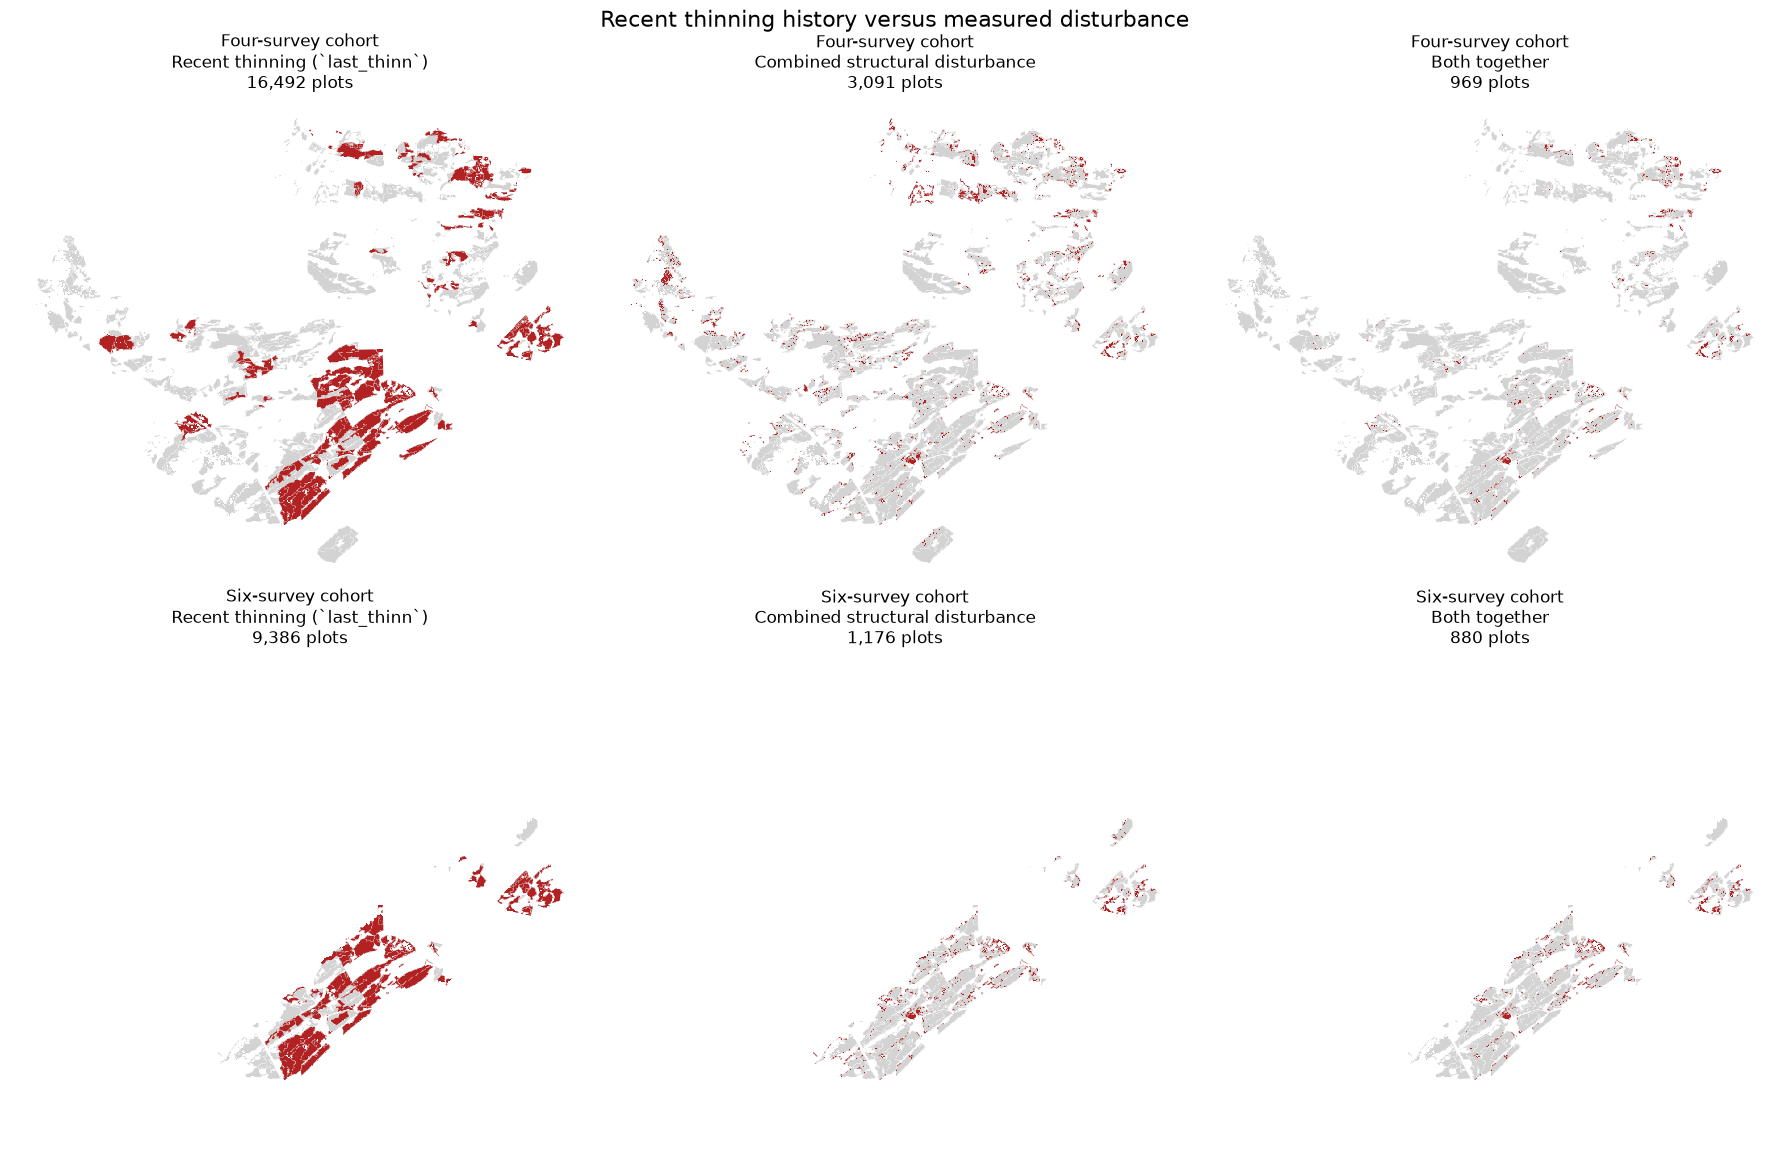

In [49]:
disturbance_alignment_summary = pd.DataFrame([
    {
        "cohort": "four_year",
        "plots": four_year_disturbance_summary["identification"].nunique(),
        "recent thinning plots": int(four_year_disturbance_summary["any_recent_thinning"].sum()),
        "combined disturbance plots": int(four_year_disturbance_summary["any_combined_structural_disturbance"].sum()),
        "overlap plots": int((four_year_disturbance_summary["any_recent_thinning"] & four_year_disturbance_summary["any_combined_structural_disturbance"]).sum()),
    },
    {
        "cohort": "six_year",
        "plots": six_year_disturbance_summary["identification"].nunique(),
        "recent thinning plots": int(six_year_disturbance_summary["any_recent_thinning"].sum()),
        "combined disturbance plots": int(six_year_disturbance_summary["any_combined_structural_disturbance"].sum()),
        "overlap plots": int((six_year_disturbance_summary["any_recent_thinning"] & six_year_disturbance_summary["any_combined_structural_disturbance"]).sum()),
    },
])
display(disturbance_alignment_summary)
display(six_year_alignment_summary)

cohort_disturbance_maps = {
    "Four-survey cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(four_year_disturbance_summary["identification"])],
        "proxy": four_year_disturbance_summary,
    },
    "Six-survey cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(six_year_disturbance_summary["identification"])],
        "proxy": six_year_disturbance_summary,
    },
}

map_layers = {
    "Recent thinning (`last_thinn`)": "any_recent_thinning",
    "Combined structural disturbance": "any_combined_structural_disturbance",
    "Both together": "recent_thinning_and_combined",
}

fig, axes = plt.subplots(2, len(map_layers), figsize=(6 * len(map_layers), 12), sharex=True, sharey=True)
for row, (cohort_name, details) in enumerate(cohort_disturbance_maps.items()):
    cohort_map = details["map"].merge(details["proxy"], on="identification", how="left")
    for col, (title, column) in enumerate(map_layers.items()):
        axis = axes[row, col]
        cohort_map.plot(ax=axis, color="lightgrey", linewidth=0)
        affected = cohort_map.loc[cohort_map[column].fillna(False)]
        if not affected.empty:
            affected.plot(ax=axis, color="firebrick", linewidth=0)
        axis.set_title(f"{cohort_name}\n{title}\n{len(affected):,} plots")
        axis.set_axis_off()
        axis.set_aspect("equal")
fig.suptitle("Recent thinning history versus measured disturbance", fontsize=16)
plt.tight_layout()
plt.show()


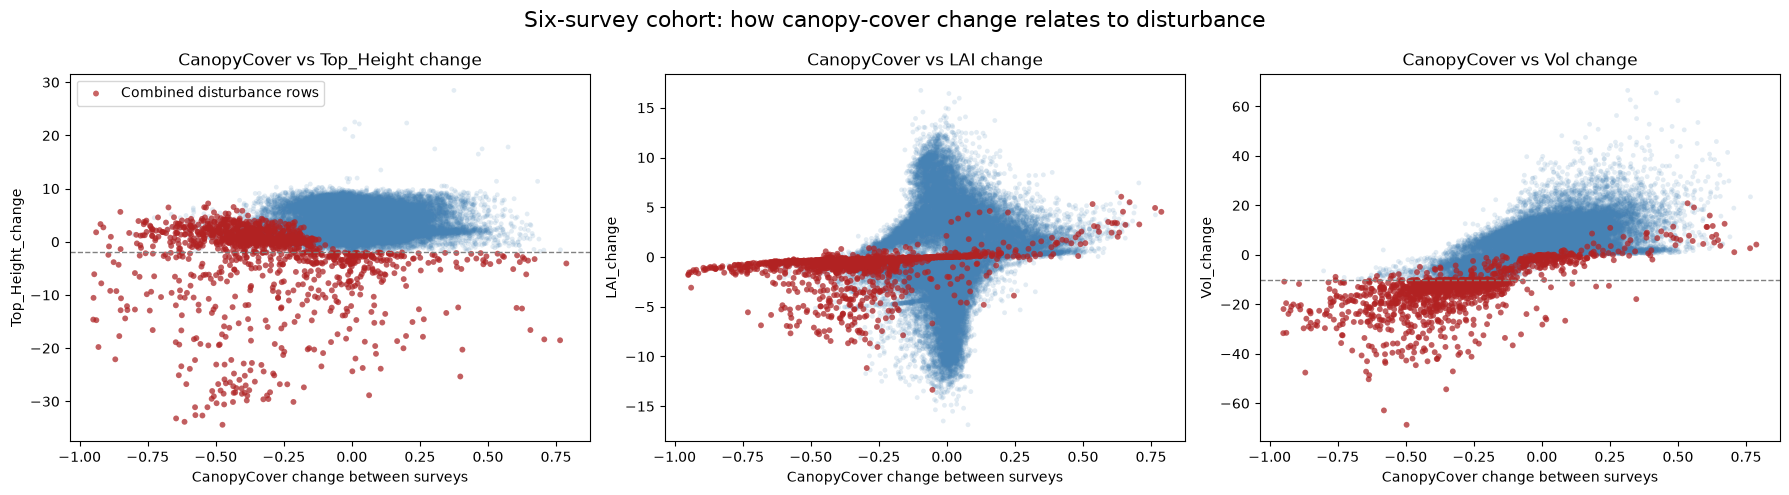

,CanopyCover_change,Top_Height_change,LAI_change,Vol_change
CanopyCover_change,1.000000,0.208155,0.394816,0.598536
Top_Height_change,0.208155,1.000000,0.554203,0.733340
LAI_change,0.394816,0.554203,1.000000,0.559842
Vol_change,0.598536,0.733340,0.559842,1.000000


In [52]:
relationship_data = six_year_events.loc[
    six_year_events[["CanopyCover_change", "Top_Height_change", "LAI_change", "Vol_change"]].notna().all(axis=1)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ("Top_Height_change", "CanopyCover vs Top_Height change"),
    ("LAI_change", "CanopyCover vs LAI change"),
    ("Vol_change", "CanopyCover vs Vol change"),
]

for axis, (y_column, title) in zip(axes, plots):
    axis.scatter(
        relationship_data["CanopyCover_change"],
        relationship_data[y_column],
        s=12,
        alpha=0.15,
        color="steelblue",
        edgecolor="none",
    )
    flagged = relationship_data.loc[relationship_data["combined_structural_disturbance"]]
    if not flagged.empty:
        axis.scatter(
            flagged["CanopyCover_change"],
            flagged[y_column],
            s=18,
            alpha=0.7,
            color="firebrick",
            edgecolor="none",
            label="Combined disturbance rows",
        )
    if y_column == "Top_Height_change":
        axis.axhline(-THINNING_ALIGNMENT_RULES["top_height_drop_threshold"], color="grey", linestyle="--", linewidth=1)
    elif y_column == "Vol_change":
        axis.axhline(-THINNING_ALIGNMENT_RULES["volume_drop_threshold"], color="grey", linestyle="--", linewidth=1)
    axis.set_xlabel("CanopyCover change between surveys")
    axis.set_ylabel(y_column)
    axis.set_title(title)

axes[0].legend()
fig.suptitle("Six-survey cohort: how canopy-cover change relates to disturbance", fontsize=16)
plt.tight_layout()
plt.show()

relationship_summary = relationship_data[[
    "CanopyCover_change", "Top_Height_change", "LAI_change", "Vol_change"
]].corr(method="spearman")
display(relationship_summary)


What this says:
1. Canopy cover aligns much more with volume change than with top-height change
That makes sense. If canopy opens up or density changes, volume can respond a lot, even when the tallest trees stay similar.
2. Top height changes only weakly with canopy-cover change
Also sensible. Thinning can remove stems without greatly affecting the tallest canopy layer.
3. Volume and top height still move together strongly
0.733 is quite strong. So height is still informative about volume, but volume is picking up additional stand-structure effects beyond just top height.

What it suggests:
- volume is more sensitive to canopy change
- top height is less sensitive to canopy change
- many plots can change in volume without much change in dominant height especially under thinning or partial removal

Top_Height is a robust growth metric, but it is relatively insensitive to partial canopy loss or stem removal. Vol is more likely to reflect felling or wind damage because it responds to stand-level biomass and stocking change, although it is also the noisier variable in this dataset.
So my recommendation would be:
- for growth modelling: Top_Height is safer
- for disturbance / felling interpretation: Vol is probably more meaningful
- best approach: discuss both, and be explicit that Vol is more sensitive but less clean

| Metric | `Top_Height` | `Vol` |
|---|---:|---:|
| Rows in cleaned cohort | 83,238 | 83,238 |
| Invalid / impossible rows | 0 | 85 negative rows |
| % invalid / impossible rows | 0.00% | 0.10% |
| Plots affected by any impossible value | 0 | 77 plots |
| Year-to-year transitions | 69,365 | 69,365 |
| Negative year-to-year changes | 2,556 | 12,247 |
| % negative year-to-year changes | 3.68% | 17.66% |
